In [1]:
!pip install pandas
!pip install yfinance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
import pandas as pd

data = {
    "Date": ["02-01-26","02-01-26","02-01-26","14-01-26","21-01-26","21-01-26"],
    "Ticker": ["BAB.L", "LLOY.L", "BARC.L", "NAVY.L", "GLEN.L", "BA.L"],
    "Action": ["Buy"]*6,
    "Shares": [7,69,11,5,5,2],
    "Price": [12.70,0.99,4.80,9.49,5.02,20.50],
    "Market Value": [88.90,68.31,52.80,47.45,25.10,41.00] #Share * Price
}

df = pd.DataFrame(data)
df

,Date,Ticker,Action,Shares,Price,Market Value
0,02-01-26,BAB.L,Buy,7,12.70,88.90
1,02-01-26,LLOY.L,Buy,69,0.99,68.31
2,02-01-26,BARC.L,Buy,11,4.80,52.80
3,14-01-26,NAVY.L,Buy,5,9.49,47.45
4,21-01-26,GLEN.L,Buy,5,5.02,25.10
5,21-01-26,BA.L,Buy,2,20.50,41.00


In [3]:
import yfinance as yf

In [4]:
tickers = df['Ticker'].tolist()
# Fetch latest prices
prices = {}
for ticker in tickers:
    try:
        ticker_yf = yf.Ticker(ticker)
        prices[ticker] = ticker_yf.history(period="1d")['Close'].iloc[-1]
    except Exception as e:
        print(f"Error with {ticker}: {e}")
        prices[ticker] = None  # in case ticker is not found

In [5]:
#This will add a column of the LIVE latest price per share for each of the Tickers
df['Latest Price'] = df['Ticker'].map(prices)
df["Latest Price"] = df["Latest Price"] / 100
df

,Date,Ticker,Action,Shares,Price,Market Value,Latest Price
0,02-01-26,BAB.L,Buy,7,12.70,88.90,12.940000
1,02-01-26,LLOY.L,Buy,69,0.99,68.31,1.038200
2,02-01-26,BARC.L,Buy,11,4.80,52.80,4.409898
3,14-01-26,NAVY.L,Buy,5,9.49,47.45,9.261000
4,21-01-26,GLEN.L,Buy,5,5.02,25.10,5.644000
5,21-01-26,BA.L,Buy,2,20.50,41.00,22.795000


In [6]:
#Calculate Unrealised gains. Unrealised Gain = Unrealised Gain=(Current Market Price − Purchase Price) × Number of Shares
df['Unrealised Gain'] = (df['Latest Price'] - df['Price']) * df['Shares']
df

,Date,Ticker,Action,Shares,Price,Market Value,Latest Price,Unrealised Gain
0,02-01-26,BAB.L,Buy,7,12.70,88.90,12.940000,1.680000
1,02-01-26,LLOY.L,Buy,69,0.99,68.31,1.038200,3.325800
2,02-01-26,BARC.L,Buy,11,4.80,52.80,4.409898,-4.291121
3,14-01-26,NAVY.L,Buy,5,9.49,47.45,9.261000,-1.145001
4,21-01-26,GLEN.L,Buy,5,5.02,25.10,5.644000,3.120001
5,21-01-26,BA.L,Buy,2,20.50,41.00,22.795000,4.590000


In [7]:
Market_Value = df["Price"] * df ["Shares"]
Market_Value.sum()

323.56

In [8]:
#Next tables
#Market Value (current price x no. of shares held) - DONE
#Unrealised Gain = Unrealised Gain=(Current Market Price − Purchase Price) × Number of Shares - DONE
#Realised gains: Profit from shares you already sold.
#Total Return = Unrealized Gains + Realized Gains
#Percentage Return: Return % = Total Return / Total Invested

In [9]:
#####Best architecture for your project#####

#If you're building a portfolio tracker, the best design is:

#transactions_df   -> buys/sells history
#prices_df         -> latest market prices (API)
#positions_df      -> aggregated holdings
#portfolio_df      -> gains / values

In [10]:
#transactions
data = {
    "Date": ["02-01-26","02-01-26","02-01-26","14-01-26","21-01-26","21-01-26"],
    "Ticker": ["BAB.L", "LLOY.L", "BARC.L", "NAVY.L", "GLEN.L", "BA.L"],
    "Action": ["Buy"]*6,
    "Shares": [7,69,11,5,5,2],
    "Price": [1270,99,480,949,502,2050]
}

transactions_df = pd.DataFrame(data)
transactions_df

,Date,Ticker,Action,Shares,Price
0,02-01-26,BAB.L,Buy,7,1270
1,02-01-26,LLOY.L,Buy,69,99
2,02-01-26,BARC.L,Buy,11,480
3,14-01-26,NAVY.L,Buy,5,949
4,21-01-26,GLEN.L,Buy,5,502
5,21-01-26,BA.L,Buy,2,2050


In [11]:
###add in any transactions (buying / selling stocks) below here to transactions_df

In [12]:
###adding new purchases or selling of stock to transactions_df######

######put any purchases or sold items at the top of coding after the transactions df so that the rest of the coding can calculate properly#####

######e.g. positive numbers for buying stock and negative numbers for selling stock#####

from datetime import datetime

new_trade = pd.DataFrame({
    "Date": [pd.Timestamp.today().normalize()],
    "Ticker": ["VWRL.L"], #I'm using the Vanguard ticker instead of the HSBC one, becuase the HSBC one doesn't download automatically and the vanguard tracks the same benchmark so it's a close match
    "Action": ["Buy"],
    "Shares": [11.98],
    "Price": [367]
})

transactions_df = pd.concat([transactions_df, new_trade], ignore_index=True)

In [13]:
#Latest LIVE Prices for my stocks
import yfinance as yf
import pandas as pd

# Convert NumPy array to a list of strings
tickers = list(transactions_df["Ticker"].unique())

# Download data
prices = yf.download(tickers, period="1d")["Close"].iloc[-1]

# If only one ticker is downloaded, prices might not be a Series
if not isinstance(prices, pd.Series):
    # Create a Series with the single price
    prices = pd.Series({tickers[0]: prices})

# Reset index to create DataFrame
prices_df = prices.reset_index()
prices_df.columns = ["Ticker", "Current Price"]

[*********************100%***********************]  7 of 7 completed


In [14]:
prices_df

,Ticker,Current Price
0,BA.L,2279.500000
1,BAB.L,1294.000000
2,BARC.L,440.989807
3,GLEN.L,564.400024
4,LLOY.L,103.820000
5,NAVY.L,926.099976
6,VWRL.L,125.851799


In [15]:
#Positions Table (Aggregated holdings)
#calculates how many shares I own per stock and the average price paid for each share
positions_df = (
    transactions_df
        .groupby("Ticker")
        .agg(
            Shares=("Shares","sum"), Avg_Cost_Per_Share=("Price","mean")
        )
        .reset_index()
)

In [16]:
positions_df

,Ticker,Shares,Avg_Cost_Per_Share
0,BA.L,2.00,2050.0
1,BAB.L,7.00,1270.0
2,BARC.L,11.00,480.0
3,GLEN.L,5.00,502.0
4,LLOY.L,69.00,99.0
5,NAVY.L,5.00,949.0
6,VWRL.L,11.98,367.0


In [17]:
#Portfolio Table (Gains + valuation)
portfolio_df = positions_df.merge(prices_df, on="Ticker")

In [18]:
portfolio_df["Market Value"] = portfolio_df["Shares"] * portfolio_df["Current Price"]

portfolio_df["Cost Basis"] = portfolio_df["Shares"] * portfolio_df["Avg_Cost_Per_Share"]

portfolio_df["Unrealised Gain"] = portfolio_df["Market Value"] - portfolio_df["Cost Basis"]

portfolio_df["Return %"] = (
    portfolio_df["Unrealised Gain"] / portfolio_df["Cost Basis"] * 100
)

In [19]:
portfolio_df

#current price is the live price for the shares
#market value = current Price * Shares
#Cost Basis = Avg_Cost_Per_Share * Shares
#Unrealised Gain  - Market Value - Costs Basis (unrealised means I haven't sold yet)

,Ticker,Shares,Avg_Cost_Per_Share,Current Price,Market Value,Cost Basis,Unrealised Gain,Return %
0,BA.L,2.00,2050.0,2279.500000,4559.000000,4100.00,459.000000,11.195122
1,BAB.L,7.00,1270.0,1294.000000,9058.000000,8890.00,168.000000,1.889764
2,BARC.L,11.00,480.0,440.989807,4850.887878,5280.00,-429.112122,-8.127124
3,GLEN.L,5.00,502.0,564.400024,2822.000122,2510.00,312.000122,12.430284
4,LLOY.L,69.00,99.0,103.820000,7163.579979,6831.00,332.579979,4.868687
5,NAVY.L,5.00,949.0,926.099976,4630.499878,4745.00,-114.500122,-2.413069
6,VWRL.L,11.98,367.0,125.851799,1507.704552,4396.66,-2888.955448,-65.707957


In [20]:
#transactions_df   → raw trade history (add bought and sold shares into this df)
#prices_df         → latest prices (API)
#positions_df      → aggregated holdings 
#portfolio_df      → gains, value, weights

In [21]:
#add historial data to my portfolio df


In [22]:
#adding Date Time column to prices_df

from datetime import date

prices_df["Date"] = date.today()
prices_df = prices_df.reset_index().rename(columns={"index": "ticker"})
prices_df = prices_df[["Date", "Ticker", "Current Price"]]
prices_df

,Date,Ticker,Current Price
0,2026-04-08,BA.L,2279.500000
1,2026-04-08,BAB.L,1294.000000
2,2026-04-08,BARC.L,440.989807
3,2026-04-08,GLEN.L,564.400024
4,2026-04-08,LLOY.L,103.820000
5,2026-04-08,NAVY.L,926.099976
6,2026-04-08,VWRL.L,125.851799


In [23]:
today_prices = prices_df.copy()

today_prices["Date"] = pd.Timestamp.today().normalize()

today_prices = today_prices[["Date", "Ticker", "Current Price"]]
today_prices

,Date,Ticker,Current Price
0,2026-04-08,BA.L,2279.500000
1,2026-04-08,BAB.L,1294.000000
2,2026-04-08,BARC.L,440.989807
3,2026-04-08,GLEN.L,564.400024
4,2026-04-08,LLOY.L,103.820000
5,2026-04-08,NAVY.L,926.099976
6,2026-04-08,VWRL.L,125.851799


In [24]:
price_history_df = pd.DataFrame(columns=["Date", "Ticker", "Current Price"])
price_history_df

,Date,Ticker,Current Price


In [25]:
price_history_df = pd.concat([price_history_df, today_prices], ignore_index=True)

price_history_df = price_history_df.drop_duplicates(["Date", "Ticker"])
price_history_df

,Date,Ticker,Current Price
0,2026-04-08,BA.L,2279.500000
1,2026-04-08,BAB.L,1294.000000
2,2026-04-08,BARC.L,440.989807
3,2026-04-08,GLEN.L,564.400024
4,2026-04-08,LLOY.L,103.820000
5,2026-04-08,NAVY.L,926.099976
6,2026-04-08,VWRL.L,125.851799


In [26]:
##TABLES##
#transactions_df   → raw trade history (add bought and sold shares into this df)
#prices_df         → latest prices (API)
#positions_df      → aggregated holdings 
#portfolio_df      → gains, value, weights
#price_history_df   → historical prices

In [27]:
#Everyday I need to:
#1 Save historical price data frame: price_history_df.to_csv("price_history.csv", index=False)
#2 Load it back up to have the historical data: price_history_df = pd.read_csv("price_history.csv", parse_dates=["Date"])

In [28]:
positions = (
    transactions_df
    .pivot_table(index="Date", columns="Ticker", values="Shares", aggfunc="sum")
    .fillna(0)
    .cumsum()
)

In [29]:
transactions_df

,Date,Ticker,Action,Shares,Price
0,02-01-26,BAB.L,Buy,7.00,1270
1,02-01-26,LLOY.L,Buy,69.00,99
2,02-01-26,BARC.L,Buy,11.00,480
3,14-01-26,NAVY.L,Buy,5.00,949
4,21-01-26,GLEN.L,Buy,5.00,502
5,21-01-26,BA.L,Buy,2.00,2050
6,2026-04-08 00:00:00,VWRL.L,Buy,11.98,367


In [30]:
prices = price_history_df.pivot(
    index="Date",
    columns="Ticker",
    values="Current Price"
)
prices

Ticker,BA.L,BAB.L,BARC.L,GLEN.L,LLOY.L,NAVY.L,VWRL.L
Date,,,,,,,
2026-04-08,2279.5,1294.0,440.989807,564.400024,103.82,926.099976,125.851799


In [31]:
# Convert indices to datetime (forces everything to same type)
prices.index = pd.to_datetime(prices.index)
positions.index = pd.to_datetime(positions.index)

# Sort indices
prices = prices.sort_index()
positions = positions.sort_index()

# Align positions with price dates
positions = positions.reindex(prices.index, method="ffill").fillna(0)

In [32]:
#Align positions with price dates

# Convert string dates to datetime objects if needed
#if isinstance(prices.index[0], str):
#    prices.index = pd.to_datetime(prices.index)
#if isinstance(positions.index[0], str):
#    positions.index = pd.to_datetime(positions.index)

# Sort the indices to ensure they are monotonic
#prices = prices.sort_index()  # Sort prices DataFrame by index
#positions = positions.sort_index()  # Sort positions DataFrame by index

# Now reindex with consistent datetime index types
#positions = positions.reindex(prices.index, method="ffill").fillna(0)

In [33]:
positions

Ticker,BA.L,BAB.L,BARC.L,GLEN.L,LLOY.L,NAVY.L,VWRL.L
Date,,,,,,,
2026-04-08,0.0,0.0,0.0,0.0,0.0,0.0,11.98


In [34]:
#Calculate portfolio value (THIS is the magic line)
portfolio_value = (positions * prices).sum(axis=1)

In [35]:
portfolio_df = portfolio_value.reset_index(name="portfolio_value")
portfolio_df

,Date,portfolio_value
0,2026-04-08,1507.704552


<Axes: title={'center': 'Portfolio Value'}, xlabel='Date'>

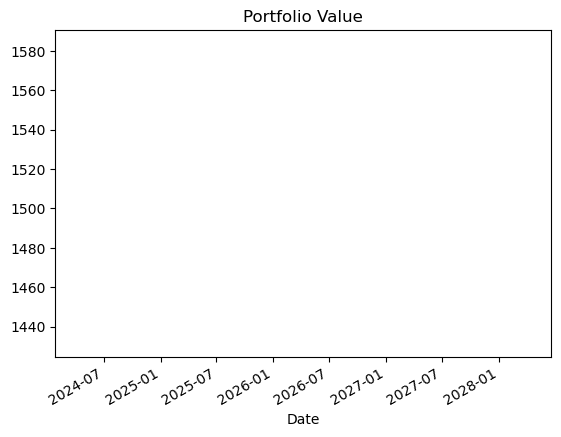

In [36]:
#Plot performance
portfolio_value.plot(title="Portfolio Value")

In [37]:
#Daily# Returns
returns = portfolio_value.pct_change()
returns

Date
2026-04-08   NaN
dtype: float64

In [38]:
#Total Profit
portfolio_value.iloc[-1] - portfolio_value.iloc[0]

0.0

In [39]:
#Drawdown
drawdown = portfolio_value / portfolio_value.cummax() - 1
drawdown

Date
2026-04-08    0.0
dtype: float64

In [40]:
#Tables - just need to maintain the top two
#transactions_df
#price_history_df


#transactions_df   → raw trade history (add bought and sold shares into this df)
#prices_df         → latest prices (API)
#positions_df      → aggregated holdings 
#portfolio_df      → gains, value, weights
#price_history_df   → historical prices

In [41]:
###automating price_history_df####

In [42]:
prices_df

,Date,Ticker,Current Price
0,2026-04-08,BA.L,2279.500000
1,2026-04-08,BAB.L,1294.000000
2,2026-04-08,BARC.L,440.989807
3,2026-04-08,GLEN.L,564.400024
4,2026-04-08,LLOY.L,103.820000
5,2026-04-08,NAVY.L,926.099976
6,2026-04-08,VWRL.L,125.851799


In [43]:
tickers = prices_df["Ticker"].tolist()

In [44]:
tickers

['BA.L', 'BAB.L', 'BARC.L', 'GLEN.L', 'LLOY.L', 'NAVY.L', 'VWRL.L']

In [45]:
price_history_df = yf.download(
    tickers,
    start="2024-01-01",  # start date of your analysis
    auto_adjust=True
)["Close"]  # only close prices

[*********************100%***********************]  7 of 7 completed


In [46]:
price_history_df.head(5)

Ticker,BA.L,BAB.L,BARC.L,GLEN.L,LLOY.L,NAVY.L,VWRL.L
Date,,,,,,,
2024-01-02,1115.526611,419.929474,155.152664,468.459045,48.021614,NaN,90.480843
2024-01-03,1133.519043,440.725922,152.994461,458.264343,47.407234,NaN,89.572273
2024-01-04,1155.009888,445.325134,155.452438,459.013916,47.517120,NaN,89.572273
2024-01-05,1152.510742,442.325653,155.472443,462.761993,47.212429,NaN,89.156647
2024-01-08,1144.514282,439.926056,154.693069,456.865021,47.517120,NaN,89.185638


In [47]:
price_history_df = (
    price_history_df
    .stack()  # turn columns into rows
    .reset_index()
)
price_history_df.columns = ["Date", "Ticker", "Price"]

In [48]:
price_history_df.head(5)

,Date,Ticker,Price
0,2024-01-02,BA.L,1115.526611
1,2024-01-02,BAB.L,419.929474
2,2024-01-02,BARC.L,155.152664
3,2024-01-02,GLEN.L,468.459045
4,2024-01-02,LLOY.L,48.021614


In [49]:
#save so you don't redownload
#price_history_df.to_csv("price_history.csv", index=False)

In [50]:
#Load it later:
#price_history_df = pd.read_csv("price_history.csv", parse_dates=["date"])

In [51]:
#Update prices for new days

import datetime

today = pd.Timestamp.today().normalize()
last_date = price_history_df["Date"].max()

# only download if there's a new date
if last_date < today:
    new_prices = yf.download(
        tickers,
        start=last_date + pd.Timedelta(days=1),
        end=today + pd.Timedelta(days=1),
        auto_adjust=True
    )["Close"]

    # convert to long format
    new_prices = new_prices.stack().reset_index()
    new_prices.columns = ["Date", "Ticker", "Price"]

    # append to history
    price_history_df = pd.concat([price_history_df, new_prices], ignore_index=True)
    price_history_df = price_history_df.drop_duplicates(["Date", "Ticker"])

In [52]:
#After this, you have a complete historical price table that can be used with your existing portfolio calculation:

# Merge positions and calculate portfolio value
merged = price_history_df.merge(positions_df, on="Ticker")
merged["value"] = merged["Price"] * merged["Shares"]

portfolio_df = merged.groupby("Date")["value"].sum().reset_index(name="portfolio_value")

In [53]:
########Tables - just need to maintain the top two ##########
#transactions_df
#price_history_df


#transactions_df   → raw trade history (add bought and sold shares into this df)
#prices_df         → latest prices (API)
#positions_df      → aggregated holdings 
#portfolio_df      → gains, value, weights
#price_history_df   → historical prices

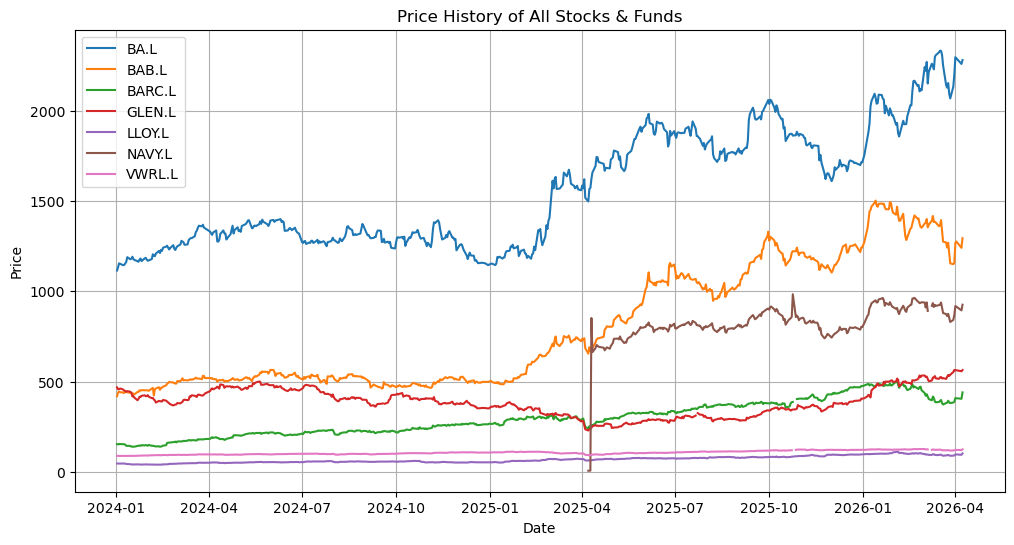

In [54]:
#Plot multiple stocks together
# Pivot to wide format: dates as index, tickers as columns
prices_wide = price_history_df.pivot(index="Date", columns="Ticker", values="Price")

plt.figure(figsize=(12,6))
for ticker in prices_wide.columns:
    plt.plot(prices_wide.index, prices_wide[ticker], label=ticker)

plt.title("Price History of All Stocks & Funds")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()

In [55]:
#visual:
#1. All individual stock prices
#2. Total portfolio value

In [56]:
#prep data
import matplotlib.pyplot as plt

# Pivot price_history_df to wide format: dates as index, tickers as columns
prices_wide = price_history_df.pivot(index="Date", columns="Ticker", values="Price")

# Calculate portfolio value
# Make sure positions_df exists with current holdings (columns: ticker, shares)
merged = price_history_df.merge(positions_df, on="Ticker")
merged["value"] = merged["Price"] * merged["Shares"]
portfolio_df = merged.groupby("Date")["value"].sum().reset_index(name="portfolio_value")
portfolio_df.set_index("Date", inplace=True)

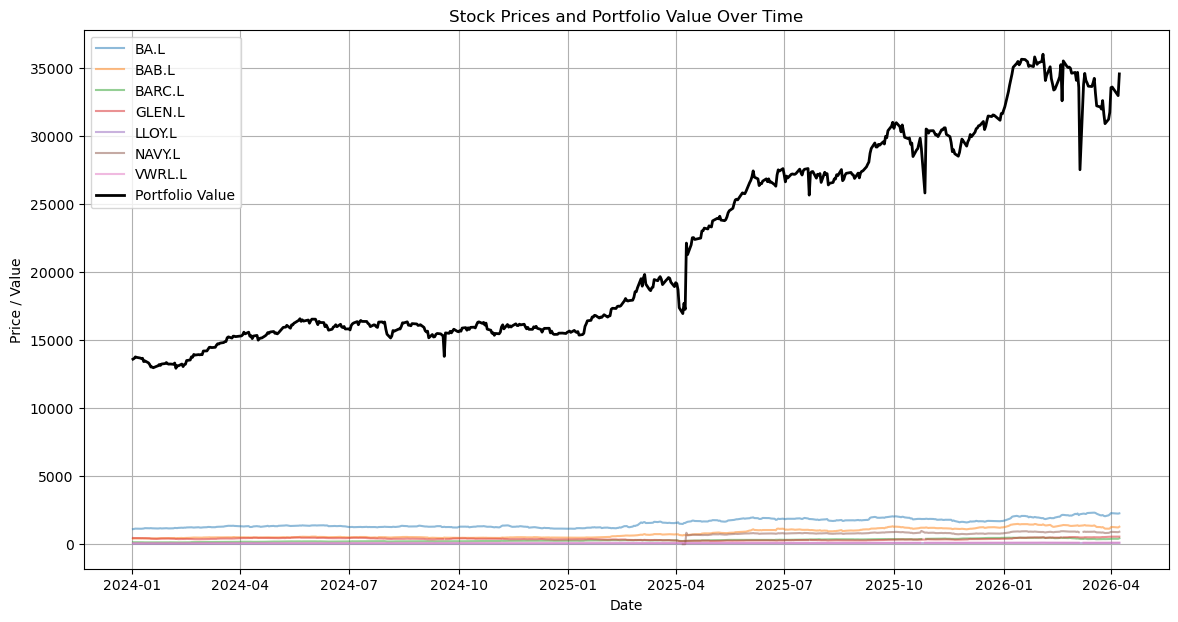

In [57]:
#Plot combined chart

plt.figure(figsize=(14,7))

# Plot individual stock prices (lighter color)
for ticker in prices_wide.columns:
    plt.plot(prices_wide.index, prices_wide[ticker], label=ticker, alpha=0.5)

# Plot portfolio value (bold)
plt.plot(portfolio_df.index, portfolio_df["portfolio_value"], label="Portfolio Value", color="black", linewidth=2)

plt.title("Stock Prices and Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Price / Value")
plt.grid(True)
plt.legend()
plt.show()

In [58]:
###adding new purchases or selling of stock to transactions_df######

######put any purchases or sold items at the top of coding after the transactions df so that the rest of the coding can calculate properly#####

######e.g. positive numbers for buying stock and negative numbers for selling stock#####

#from datetime import datetime

#new_trade = pd.DataFrame({
#    "Date": [pd.Timestamp.today().normalize()],
#    "Ticker": ["BA.L"],
#    "Action": ["Buy"/"Sell"],
#    "Shares": [50],
#    "Price": [2200.0]
#})

#transactions_df = pd.concat([transactions_df, new_trade], ignore_index=True)

In [59]:
########Tables - just need to maintain the top two ##########
#transactions_df
#price_history_df


#transactions_df   → raw trade history (add bought and sold shares into this df)
#prices_df         → latest prices (API)
#positions_df      → aggregated holdings 
#portfolio_df      → gains, value, weights
#price_history_df   → historical prices

In [60]:
price_history_df.to_csv("price_history.csv", index=False)

In [61]:
price_history_df

,Date,Ticker,Price
0,2024-01-02,BA.L,1115.526611
1,2024-01-02,BAB.L,419.929474
2,2024-01-02,BARC.L,155.152664
3,2024-01-02,GLEN.L,468.459045
4,2024-01-02,LLOY.L,48.021614
...,...,...,...
3685,2026-04-08,BARC.L,440.989807
3686,2026-04-08,GLEN.L,564.510010
3687,2026-04-08,LLOY.L,103.839996
3688,2026-04-08,NAVY.L,926.099976


In [62]:
#I am downsampling price_history_df so that it is showing the weekly costs rather than the daily ones
#This will help me with forecasting as I shouldn't have any missing dates

import pandas as pd

# Convert Date column to datetime with error handling
price_history_df["Date"] = pd.to_datetime(price_history_df["Date"], errors='coerce')

# Drop rows with NaT values to prevent the error
price_history_df = price_history_df.dropna(subset=["Date"])

# Fix: Set both Date and Ticker as index before resampling
weekly = (
    price_history_df.set_index(["Date", "Ticker"])  # Set both as index
      .groupby(level="Ticker")                      # Group by the Ticker level
      .resample("W", level="Date")                  # Resample on the Date level
      .last()                                       # Last price of the week
      .reset_index()                                # Reset both indices to columns
)

print(weekly)

     Ticker       Date        Price
0      BA.L 2024-01-07  1152.510742
1      BA.L 2024-01-14  1188.995483
2      BA.L 2024-01-21  1173.501953
3      BA.L 2024-01-28  1167.504639
4      BA.L 2024-02-04  1171.502930
..      ...        ...          ...
762  VWRL.L 2026-03-15   123.427620
763  VWRL.L 2026-03-22   120.500000
764  VWRL.L 2026-03-29   119.019997
765  VWRL.L 2026-04-05   122.800003
766  VWRL.L 2026-04-12   125.851799

[767 rows x 3 columns]


In [63]:
weekly.to_csv("weekly_price_history_df.csv", index=False)

In [64]:
weekly

,Ticker,Date,Price
0,BA.L,2024-01-07,1152.510742
1,BA.L,2024-01-14,1188.995483
2,BA.L,2024-01-21,1173.501953
3,BA.L,2024-01-28,1167.504639
4,BA.L,2024-02-04,1171.502930
...,...,...,...
762,VWRL.L,2026-03-15,123.427620
763,VWRL.L,2026-03-22,120.500000
764,VWRL.L,2026-03-29,119.019997
765,VWRL.L,2026-04-05,122.800003


In [65]:
###FORECASTING Using the 'weekly' data frame

# First, install the prophet package
!pip install prophet

# Then import the modules
from prophet import Prophet
import pandas as pd

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


10:56:05 - cmdstanpy - INFO - Chain [1] start processing
10:56:05 - cmdstanpy - INFO - Chain [1] done processing


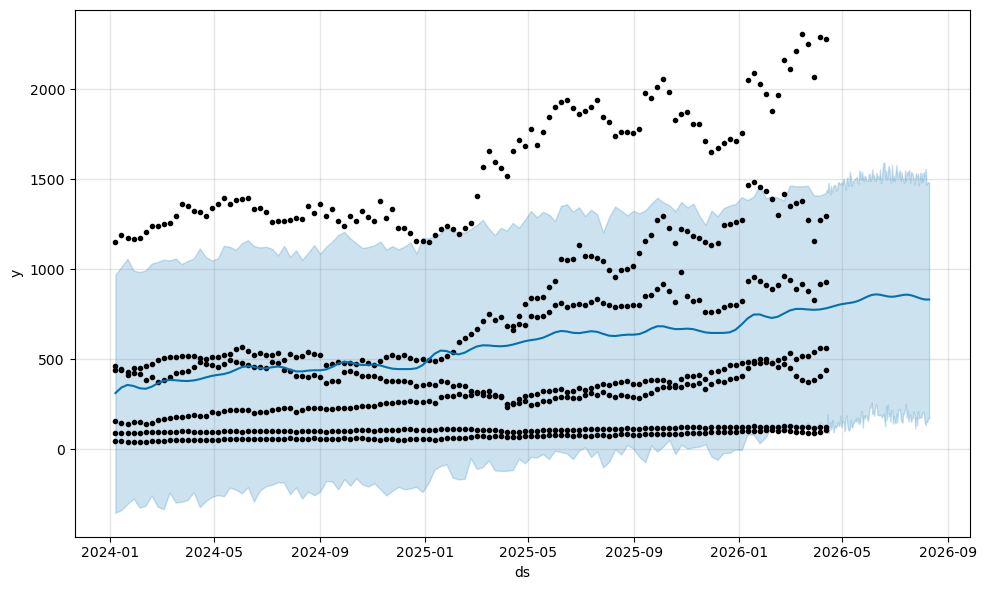

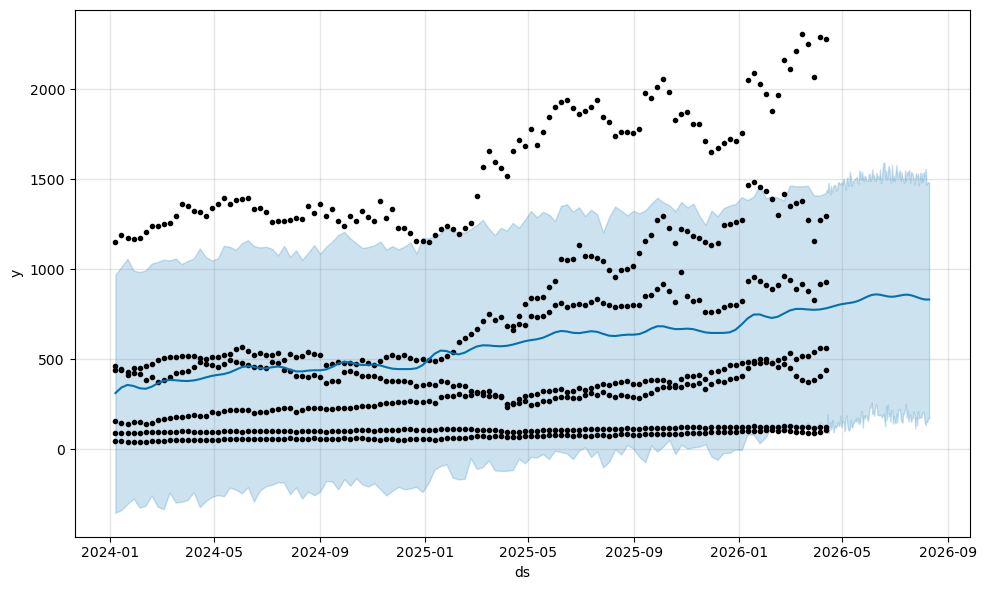

In [66]:
weekly = weekly.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(weekly)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)



In [67]:
weekly

,Ticker,ds,y
0,BA.L,2024-01-07,1152.510742
1,BA.L,2024-01-14,1188.995483
2,BA.L,2024-01-21,1173.501953
3,BA.L,2024-01-28,1167.504639
4,BA.L,2024-02-04,1171.502930
...,...,...,...
762,VWRL.L,2026-03-15,123.427620
763,VWRL.L,2026-03-22,120.500000
764,VWRL.L,2026-03-29,119.019997
765,VWRL.L,2026-04-05,122.800003


In [68]:
#I'll need to do the prophet forecast (code above) for each stock share price
#so I'll need to filter the weekly df by the ticker

In [69]:
#Created a df for each stock so that I can use prophet to calculate the forecast
BA_L = weekly[weekly["Ticker"] == "BA.L"]
BAB_L = weekly[weekly["Ticker"] == "BAB.L"]
BARC_L = weekly[weekly["Ticker"] == "BARC.L"]
GLEN_L = weekly[weekly["Ticker"] == "GLEN.L"]
LLOY_L = weekly[weekly["Ticker"] == "LLOY.L"]
NAVY_L = weekly[weekly["Ticker"] == "NAVY.L"]
VWRL_L = weekly[weekly["Ticker"] == "VWRL.L"]

10:56:06 - cmdstanpy - INFO - Chain [1] start processing
10:56:06 - cmdstanpy - INFO - Chain [1] done processing


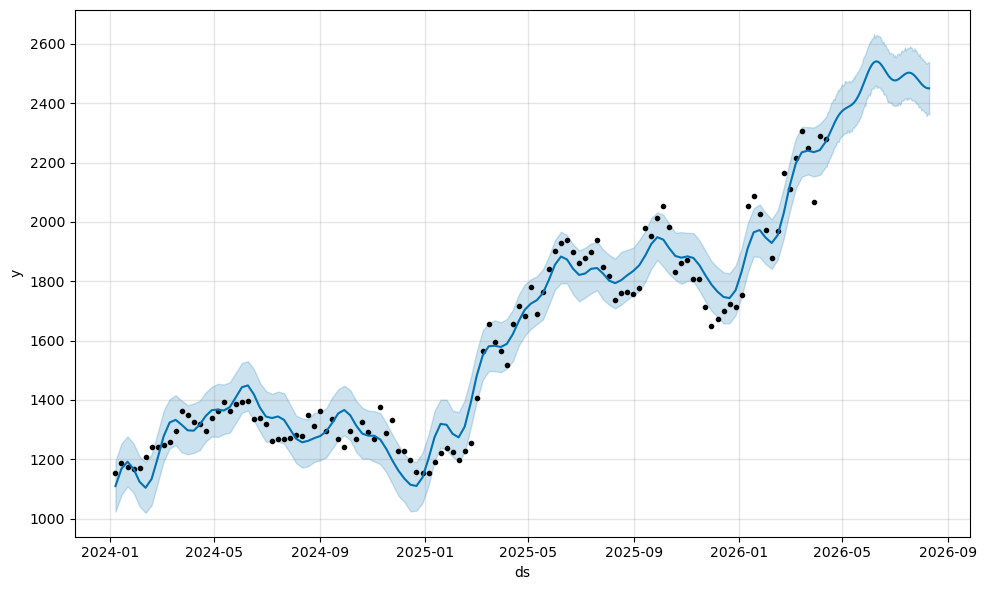

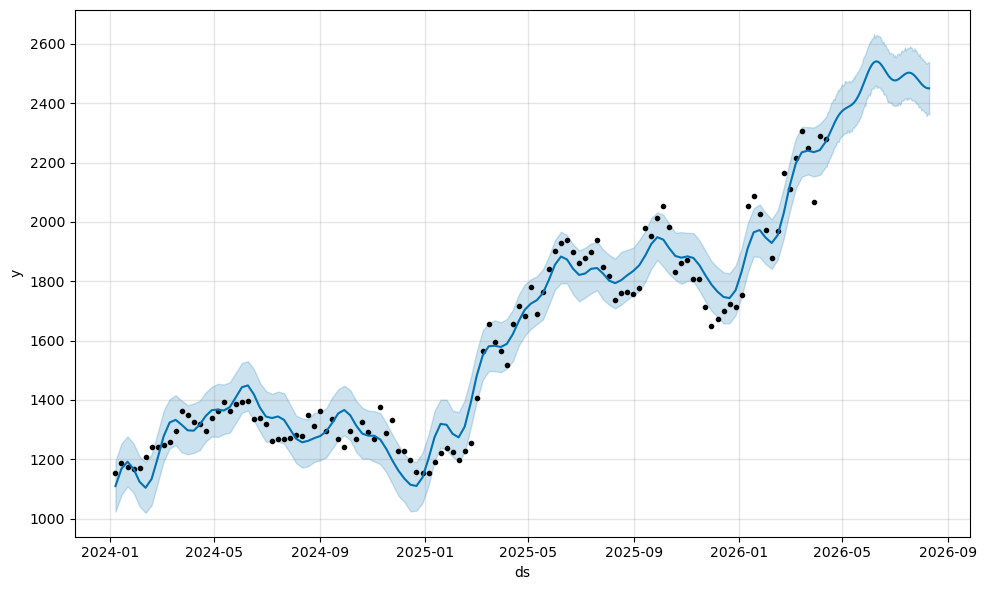

In [70]:
#BAE Forecast
BA_L= BA_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(BA_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)

10:56:07 - cmdstanpy - INFO - Chain [1] start processing
10:56:07 - cmdstanpy - INFO - Chain [1] done processing


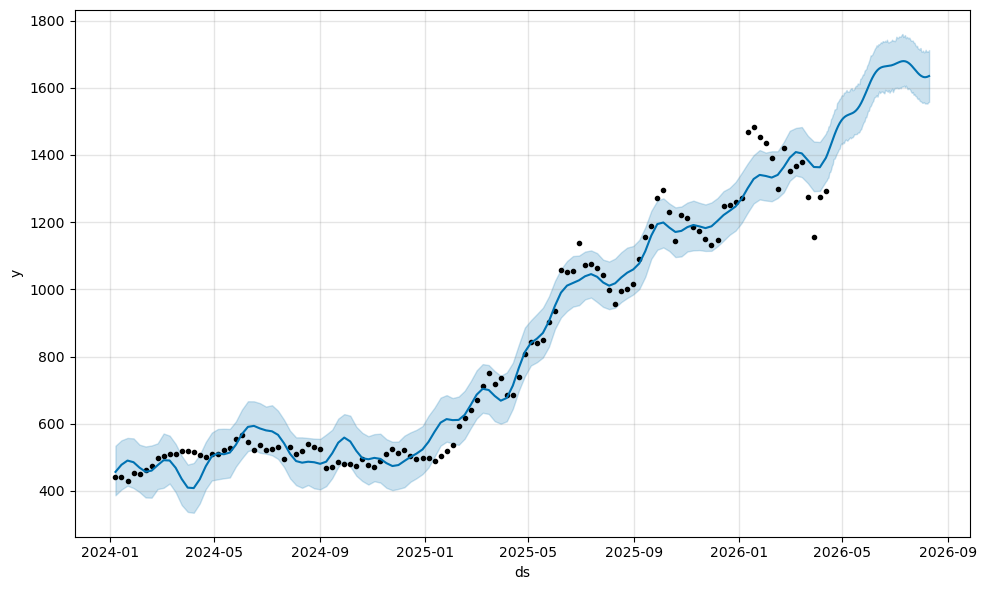

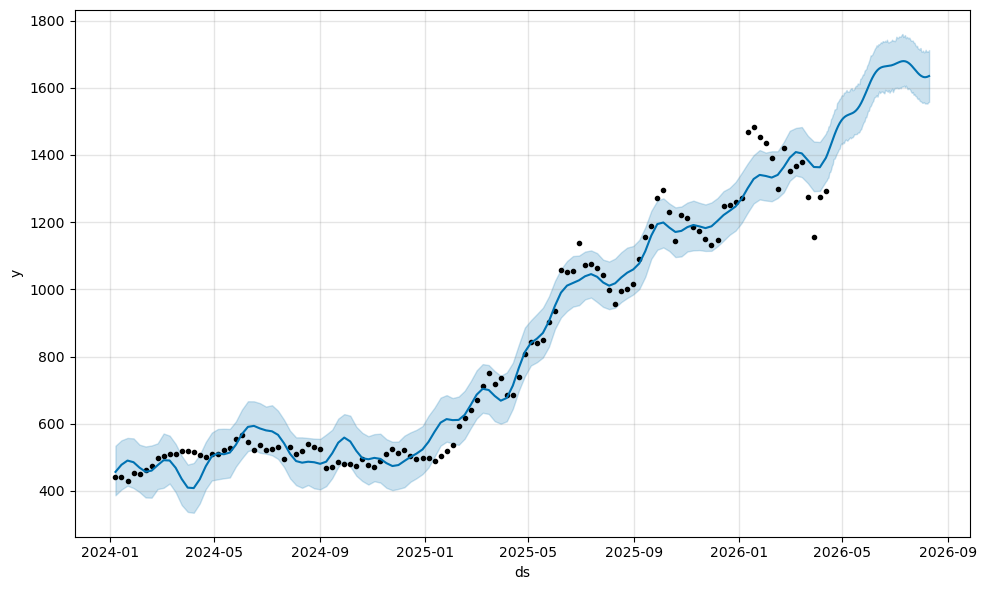

In [71]:
#Babcock Forecast
BAB_L = BAB_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(BAB_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)


10:56:08 - cmdstanpy - INFO - Chain [1] start processing
10:56:08 - cmdstanpy - INFO - Chain [1] done processing


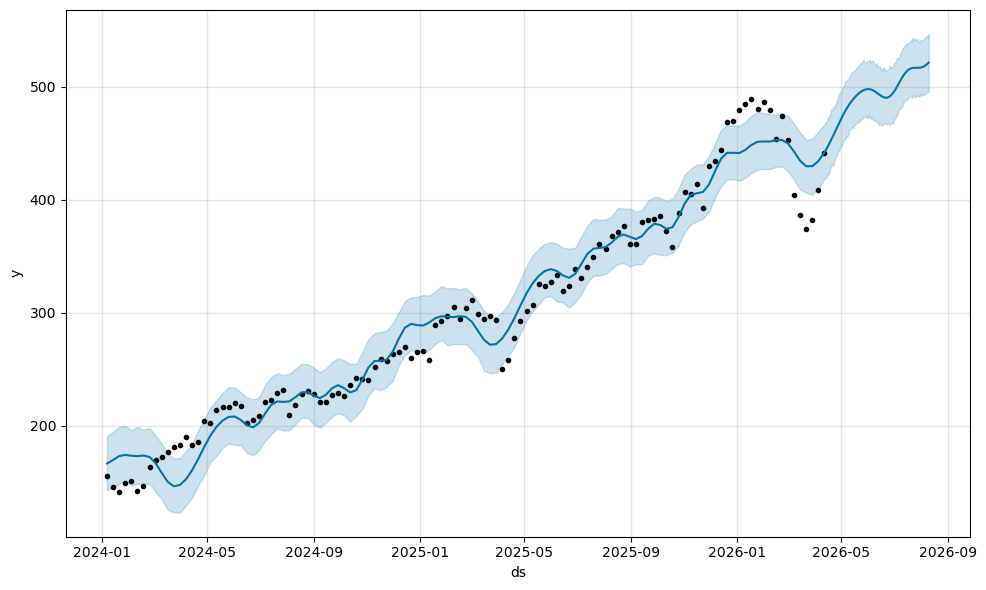

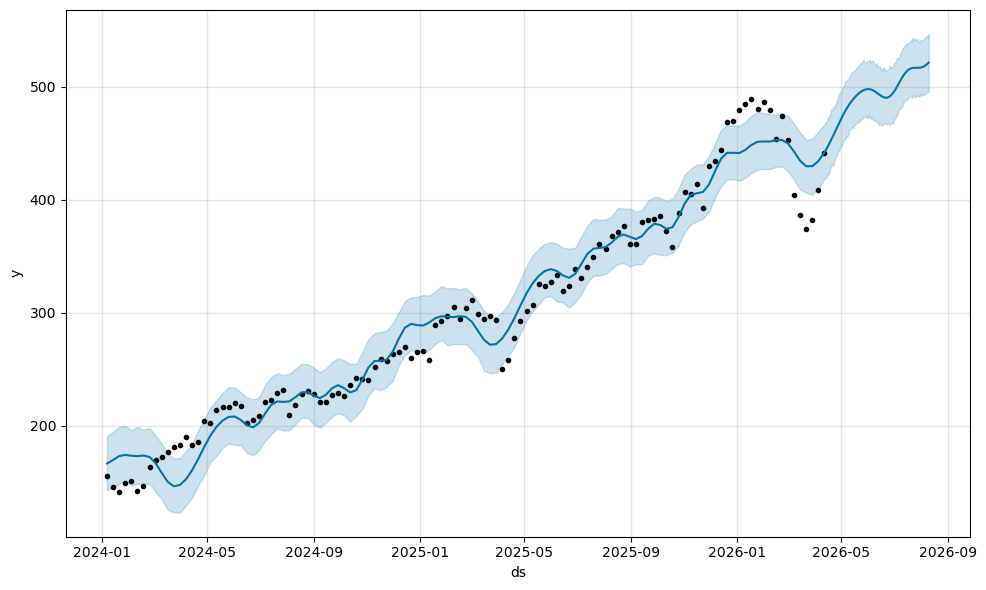

In [72]:
#Barclays Forecast
BARC_L= BARC_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(BARC_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)

10:56:09 - cmdstanpy - INFO - Chain [1] start processing
10:56:09 - cmdstanpy - INFO - Chain [1] done processing


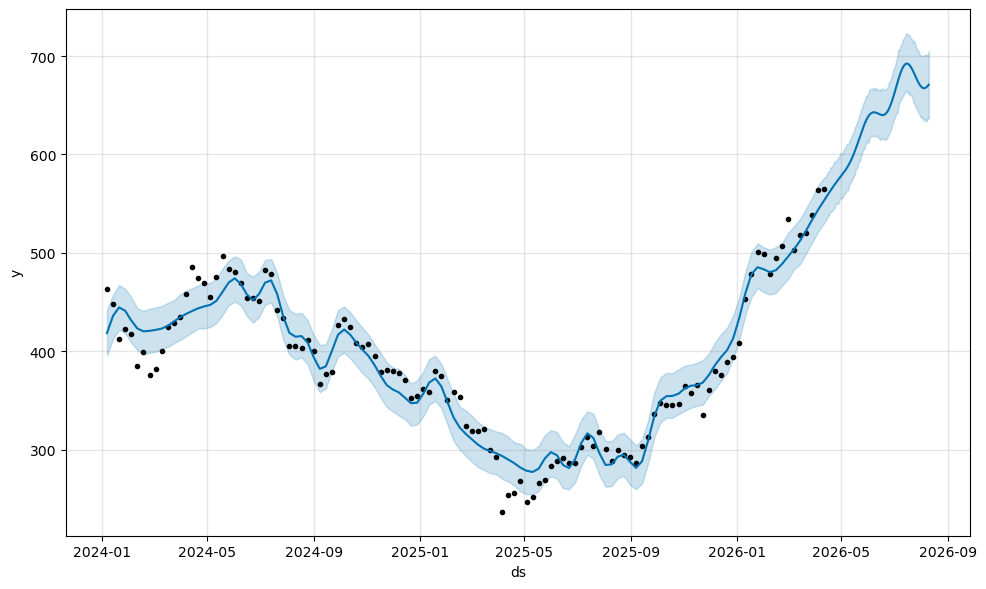

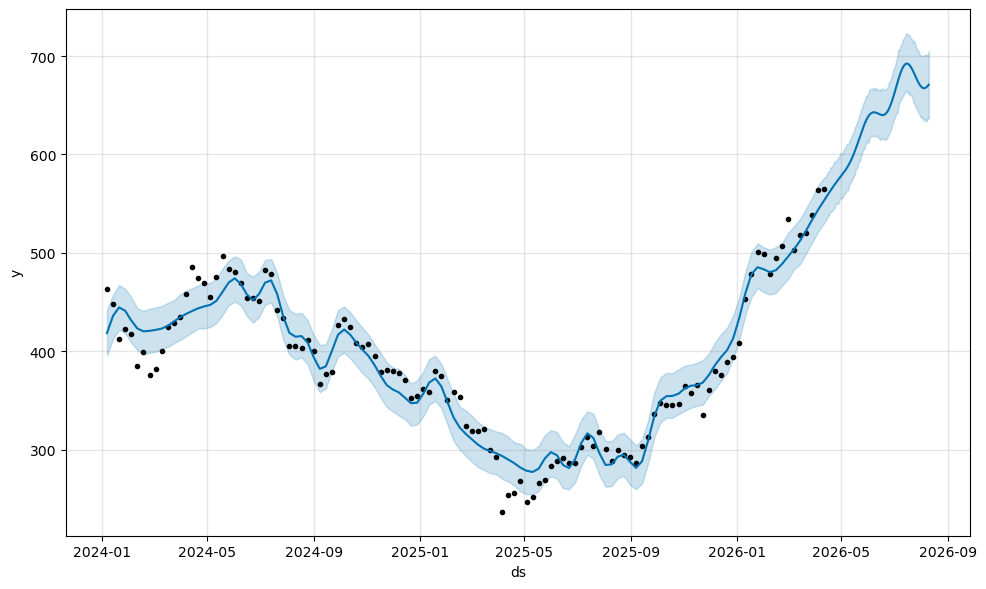

In [73]:
#Glencore Forecast
GLEN_L= GLEN_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(GLEN_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)

10:56:10 - cmdstanpy - INFO - Chain [1] start processing
10:56:10 - cmdstanpy - INFO - Chain [1] done processing


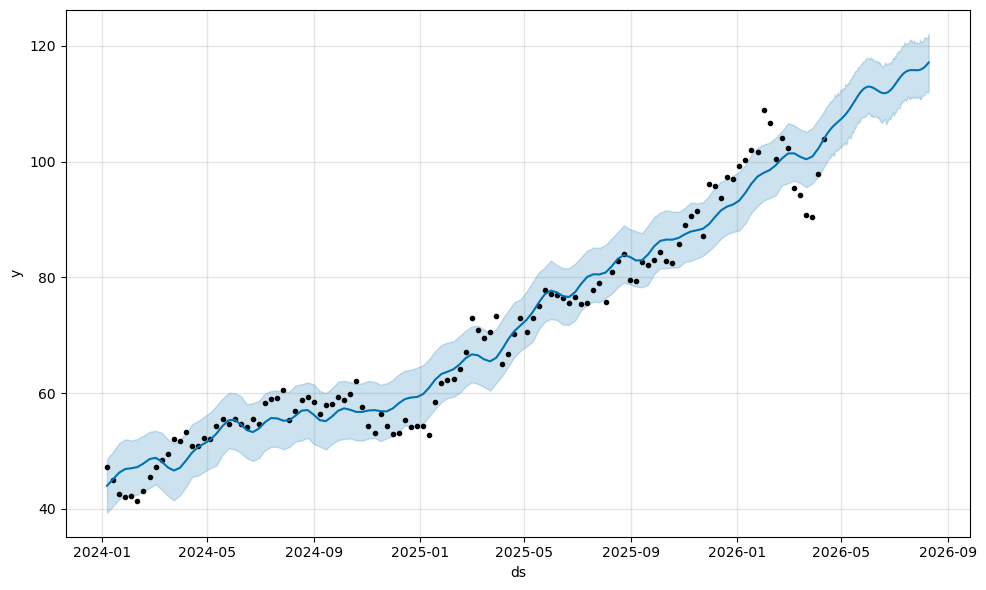

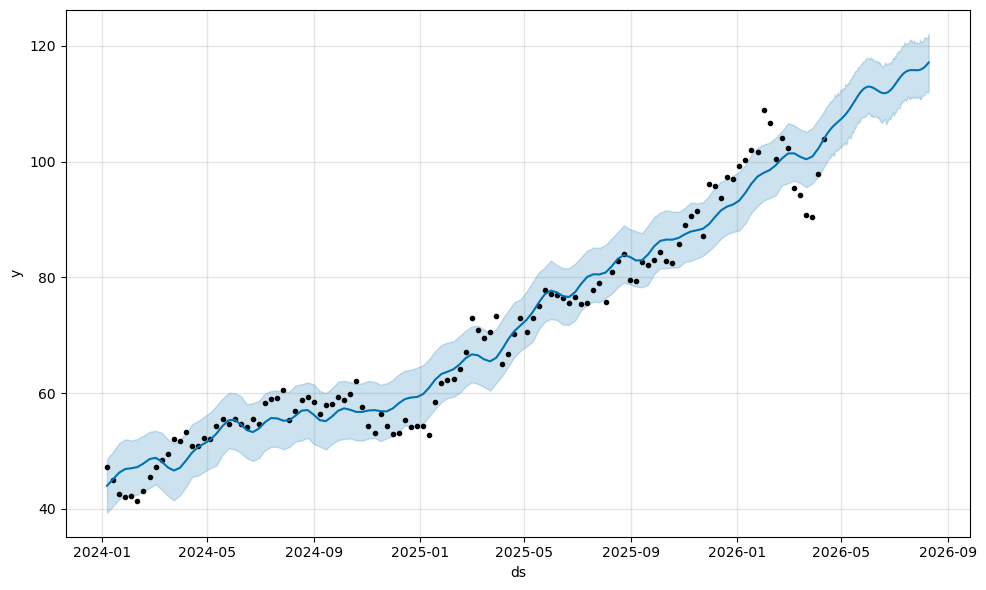

In [74]:
#Lloyd Forecast
LLOY_L= LLOY_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(LLOY_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)

10:56:10 - cmdstanpy - INFO - Chain [1] start processing
10:56:11 - cmdstanpy - INFO - Chain [1] done processing


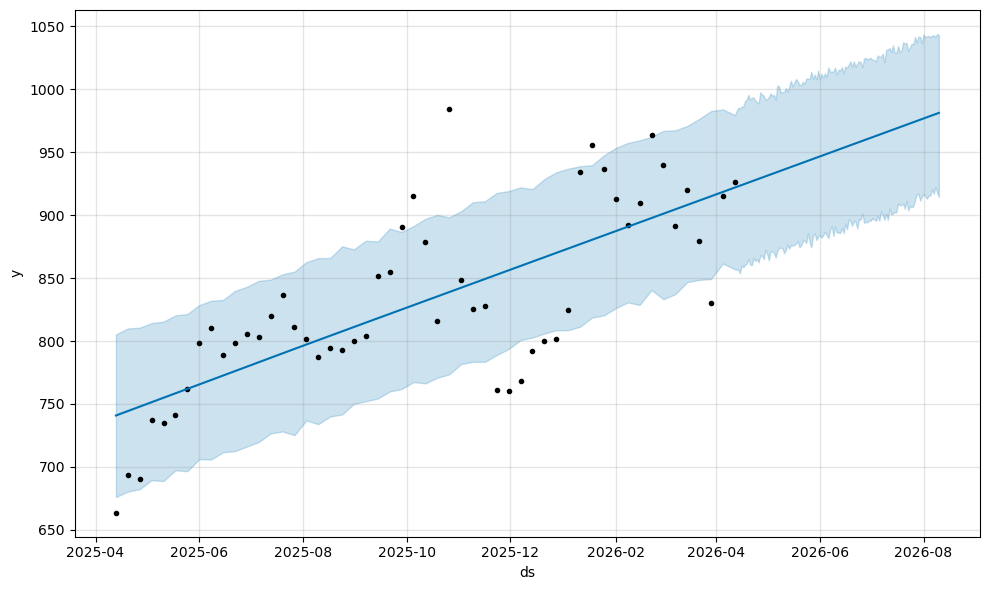

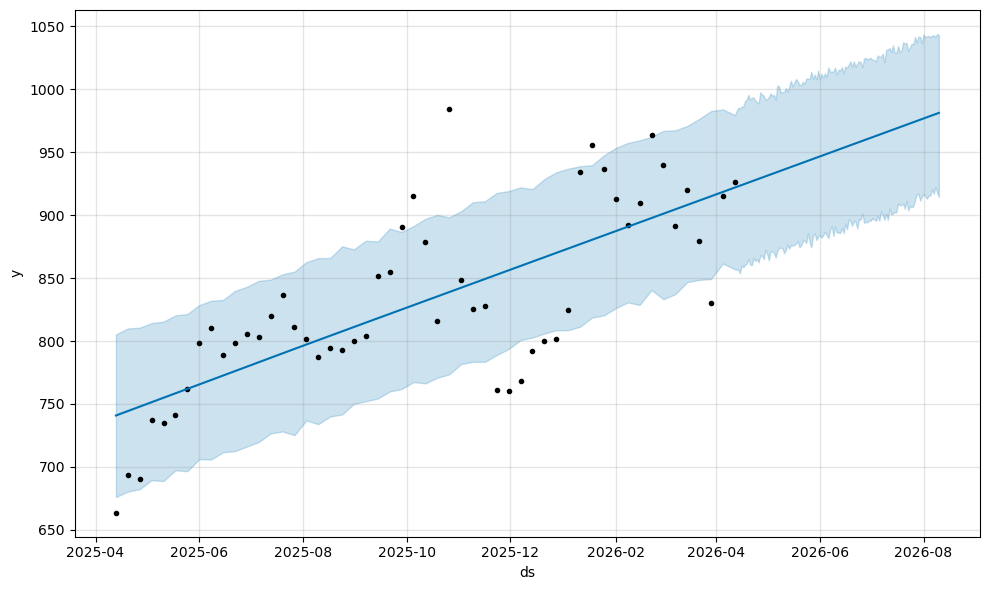

In [75]:
#Future of Euro Defence Forecast
NAVY_L= NAVY_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(NAVY_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)

10:56:11 - cmdstanpy - INFO - Chain [1] start processing
10:56:11 - cmdstanpy - INFO - Chain [1] done processing


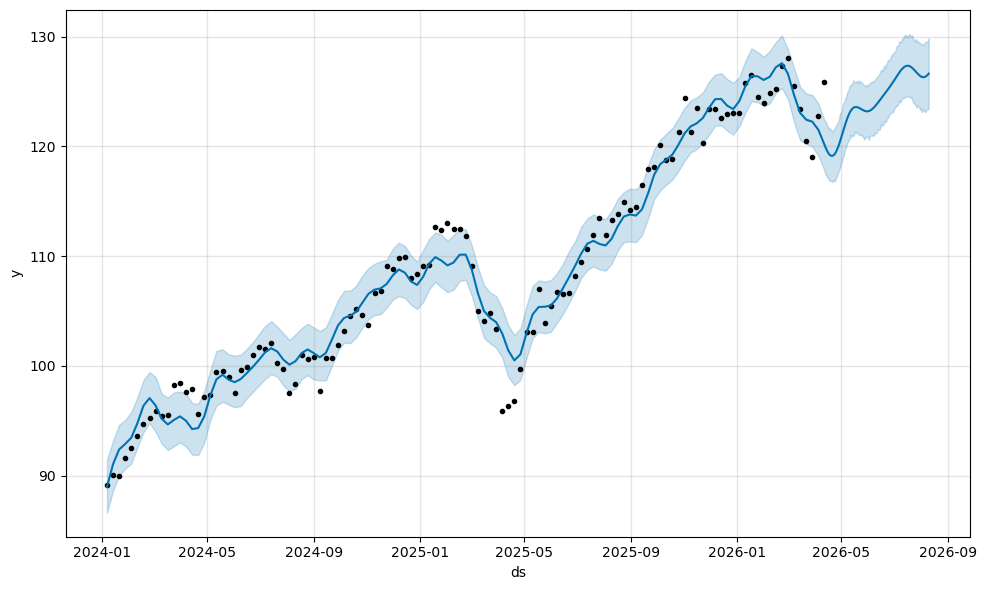

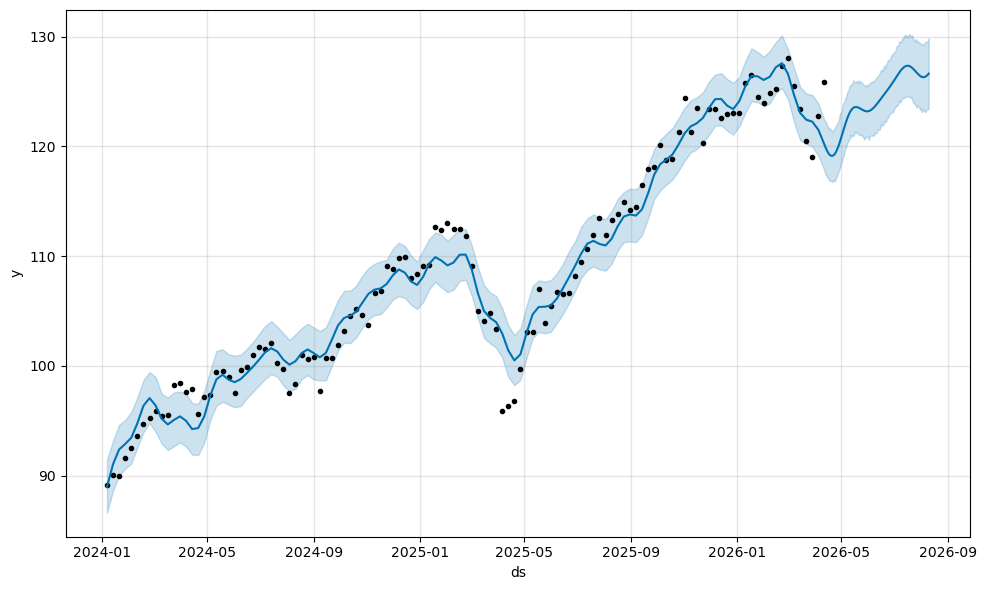

In [76]:
#Vanguard Forecast
VWRL_L= VWRL_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(VWRL_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)